#### Física de la Radioterapia. Máster de Física Biomédica. Universidad Complutense de Madrid
# `OpenTPS` en **Colab**
## Cálculo de un tratamiento simple de **protonterapia** de próstata
-----

Este cuaderno sirve de plantilla de ejemplo de cómo diseñar un tratamiento, optimizarlo y calcular su distribución de dosis asociada mediante `OpenTPS`.

> La instalación en Colab es todavía experimental y requiere utilizar pip sobre la distribución del paquete. No hemos conseguido instalarla utilizando **uv** por problemas de compatibilidad entre las versiones de `numpy` y `scipy`

> El entorno de ejecución puede ser basado en CPU o en GPU. El uso de cupy en `OpenTPS` (entornos GPU`) es experimental. No hemos conseguido las ganancias de velocidad de ejecución de las que habla la documentación de `OpenTPS` que podrían ser hasta de 18X.

In [ ]:
import sys

if "google.colab" in sys.modules:
  from IPython import get_ipython
  get_ipython().system('git clone https://gitlab.com/openmcsquare/opentps.git')
  get_ipython().system('pip install ./opentps')
  output = get_ipython().system('nvidia-smi -L')

  # Ensure output_str is always a string, even if output is None
  if output is None:
    output_str = ""
  else:
    output_str = output.decode('utf-8') if isinstance(output, bytes) else output

  if "No devices found" in output_str:
    print("El entorno de ejecución es CPU.")
  else:
    get_ipython().system('uv pip install cupy-cuda12x')


Cloning into 'opentps'...
remote: Enumerating objects: 32976, done.
remote: Counting objects: 100% (3863/3863), done.
remote: Compressing objects: 100% (650/650), done.
remote: Total 32976 (delta 3182), reused 3767 (delta 3126), pack-reused 29113 (from 1)
Receiving objects: 100% (32976/32976), 850.85 MiB | 27.03 MiB/s, done.
Resolving deltas: 100% (24256/24256), done.
Updating files: 100% (1015/1015), done.
Processing ./opentps
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

GPU 0: Tesla T4 (UUID: GPU-01d03175-82e7-bc7a-f495-50df205c3e84)
Using Python 3.12.12 environment at: /usr
Audited 1 package in 155ms


Importación de módulos de `OpenTPS`

In [ ]:
from opentps.core.data.images import CTImage
from opentps.core.data.images import ROIMask
from opentps.core.data.plan import ProtonPlanDesign
from opentps.core.data import DVH
from opentps.core.data import Patient
from opentps.core.io import mcsquareIO
from opentps.core.io.scannerReader import readScanner
from opentps.core.processing.doseCalculation.doseCalculationConfig import DoseCalculationConfig
from opentps.core.processing.doseCalculation.protons.mcsquareDoseCalculator import MCsquareDoseCalculator
from opentps.core.processing.imageProcessing.resampler3D import resampleImage3DOnImage3D,resampleImage3D

from opentps.core.io.dataLoader import readData


11/02/2026 11:56:47 AM - root - INFO - Loading logging configuration: /usr/local/lib/python3.12/dist-packages/opentps/core/config/logger/logging_config.json
11/02/2026 11:56:47 AM - opentps.core._loggingConfig - INFO - Log level set: INFO


/usr/local/lib/python3.12/dist-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


## Estudio del paciente y configuración del planificador

Descargar y cargar los datos del paciente de próstata

In [ ]:
%%bash
# Ejecutar código Python para descargar los datos del Drive
python << EOF > /dev/null 2>&1
# Descargar los datos compartidos de Google Drive
import gdown
url = 'https://drive.google.com/file/d/1iB2dlt6QKEcI_n92mv9jMbwqy4ZuMKjn/view?usp=sharing'
output = '/content/Prostate.zip'
gdown.download(url, output, quiet=True, fuzzy=True)
EOF

# Extracción de los datos para el cálculo de dosis de ejemplo

# Descomprimir archivo de datos
unzip /content/Prostate.zip -d /content/ >/dev/null

# Eliminar el archivo comprimido
rm -f /content/Prostate.zip

In [ ]:
patientDataPath = "/content/PatientID/"
patientData = readData(patientDataPath)

11/02/2026 11:57:02 AM - opentps.core.io.dataLoader - INFO - Loading data 1/127 Dicom files : CT1.2.246.352.221.46289637177583767086002494360155930553.dcm.
11/02/2026 11:57:02 AM - opentps.core.io.dataLoader - INFO - Loading data 2/127 Dicom files : CT1.2.246.352.221.463713292774024375410748421067560572040.dcm.
11/02/2026 11:57:02 AM - opentps.core.io.dataLoader - INFO - Loading data 3/127 Dicom files : CT1.2.246.352.221.464001482127522743612166699020837920151.dcm.
11/02/2026 11:57:02 AM - opentps.core.io.dataLoader - INFO - Loading data 4/127 Dicom files : CT1.2.246.352.221.464209141697279559913540497165389702563.dcm.
11/02/2026 11:57:02 AM - opentps.core.io.dataLoader - INFO - Loading data 5/127 Dicom files : CT1.2.246.352.221.465693264907302273610733635548821593767.dcm.
11/02/2026 11:57:02 AM - opentps.core.io.dataLoader - INFO - Loading data 6/127 Dicom files : CT1.2.246.352.221.468503210913591280717978171650093844911.dcm.
11/02/2026 11:57:02 AM - opentps.core.io.dataLoader - INFO 

In [ ]:
# Escáner de simulación
ct = patientData[1]

# Estructuras de interés delimitadas
rt_struct= patientData[0]

#  Listar los nombres de los ROI y los volúmenes objetivo
rt_struct.print_ROINames()



RT Struct UID: 1.2.246.352.205.4680425589062369469.17294819384472381854
  [0]  BODY
  [1]  Vejiga
  [2]  Recto
  [3]  PTV vvss
  [4]  PTV prostata
  [5]  PTV gg
  [6]  Intestino
  [7]  CTV vvss
  [8]  CTV prostata
  [9]  CTV gg
  [10]  Cabeza femoral I
  [11]  Cabeza femoral D
  [12]  Bulbo peneano
  [13]  CouchSurface
  [14]  CouchInterior


Definición del volumen blanco y los órganos de riesgo

In [ ]:
# Definir el volumen objetivo
target = rt_struct.getContourByName('PTV prostata').getBinaryMask(origin=ct.origin,gridSize=ct.gridSize,spacing=ct.spacing)

# Definir los órganos de riesgo relevantes
OAR_rectum = rt_struct.getContourByName("Recto").getBinaryMask(origin=ct.origin,gridSize=ct.gridSize,spacing=ct.spacing)
OAR_bladder = rt_struct.getContourByName("Vejiga").getBinaryMask(origin=ct.origin,gridSize=ct.gridSize,spacing=ct.spacing)
BODY = rt_struct.getContourByName("BODY").getBinaryMask(origin=ct.origin,gridSize=ct.gridSize,spacing=ct.spacing)

Leer la curva de calibración del escáner, curva que relaciona el número Hounsfield con las propiedades físicas de los materiales, en este caso el poder de frenado relativo al agua. Leer la configuración del motor de cálculo.

In [ ]:
ctCalibration = readScanner(DoseCalculationConfig().scannerFolder)
bdl = mcsquareIO.readBDL(DoseCalculationConfig().bdlFile)

# ## Configuración de MCSquare

mc2 = MCsquareDoseCalculator()
mc2.beamModel = bdl
mc2.nbPrimaries = 5e2
mc2.ctCalibration = ctCalibration

## Diseño del plan
-----------
Para mantener simple la plantilla de ejemplo diseñamos un plan con un único campo.
Hay mucho parámetros que afectan el tiempo de cálculo
 * **targetMargin** : A mayor margen mayor tiempo para hacer la dilación del objetivo
 * **spotSpacing** : A menor separación de los spots mayor número de spots
 * **layerSpacing** : A menor separación entre capas mayor número de spots

In [ ]:
beamNames = ["Beam1"]
gantryAngles = [90.]
couchAngles = [0.]

planInit = ProtonPlanDesign()
planInit.ct = ct
planInit.gantryAngles = gantryAngles
planInit.beamNames = beamNames
planInit.couchAngles = couchAngles
planInit.calibration = ctCalibration
planInit.spotSpacing = 6.0
planInit.layerSpacing = 6.0
planInit.targetMargin = 0.0

# Set scoring parameters first to determine the scoring grid
planInit.setScoringParameters(scoringSpacing=[2, 2, 2], adapt_gridSize_to_new_spacing=True)

# Get the determined scoring grid parameters
scoring_origin = planInit.scoringOrigin
scoring_gridSize = planInit.scoringGridSize
scoring_spacing = planInit.scoringVoxelSpacing

# Resample target and BODY masks to the scoring grid
# Create new ROIMask objects from the resampled Image3D to maintain type compatibility
resampled_target_image = resampleImage3D(target, origin=scoring_origin, gridSize=scoring_gridSize, spacing=scoring_spacing)
target = ROIMask(imageArray=resampled_target_image.imageArray,
                   origin=resampled_target_image.origin,
                   spacing=resampled_target_image.spacing)
target.name = "PTV prostata_resampled"

resampled_body_image = resampleImage3D(BODY, origin=scoring_origin, gridSize=scoring_gridSize, spacing=scoring_spacing)
BODY = ROIMask(imageArray=resampled_body_image.imageArray,
                origin=resampled_body_image.origin,
                spacing=resampled_body_image.spacing)
BODY.name = "BODY_resampled"

# needs to be called after scoringGrid settings but prior to spot placement
planInit.defineTargetMaskAndPrescription(target = target, targetPrescription = 70.)

Determinar la localización de los spots

In [ ]:
plan = planInit.buildPlan()
plan.PlanName = "ProstatePlan"

11/02/2026 11:57:13 AM - opentps.core.data.plan._protonPlanDesign - INFO - Building plan ...
11/02/2026 11:57:13 AM - opentps.core.processing.planOptimization.planInitializer - INFO - Target is dilated using a margin of 0.0 mm. This process might take some time.
11/02/2026 11:57:13 AM - opentps.core.processing.imageProcessing.roiMasksProcessing - INFO - Using cupy to dilate mask
11/02/2026 11:57:38 AM - opentps.core.data.plan._protonPlanDesign - INFO - New proton plan created in 25.158530712127686 sec
11/02/2026 11:57:38 AM - opentps.core.data.plan._protonPlanDesign - INFO - Number of spots: 775


Cálculo de los beamlets

In [ ]:
beamlets = mc2.computeBeamlets(ct, plan, roi=[target])
plan.planDesign.beamlets = beamlets

11/02/2026 11:57:38 AM - opentps.core.processing.doseCalculation.protons.mcsquareDoseCalculator - INFO - Prepare MCsquare Beamlet calculation
11/02/2026 11:57:39 AM - opentps.core.io.mhdIO - INFO - Write MHD file: /root/openTPS_workspace/Simulations/MCsquare_simulation/CT.mhd
11/02/2026 11:57:40 AM - opentps.core.io.mcsquareIO - INFO - Write plan: /root/openTPS_workspace/Simulations/MCsquare_simulation/PlanPencil.txt
11/02/2026 11:57:40 AM - opentps.core.processing.doseCalculation.protons.mcsquareDoseCalculator - INFO - Start MCsquare simulation
11/02/2026 12:01:41 PM - opentps.core.io.mcsquareIO - INFO - Read sparse beamlets: /root/openTPS_workspace/Simulations/MCsquare_simulation/Outputs/Sparse_Dose.txt
11/02/2026 12:01:41 PM - opentps.core.io.mcsquareIO - INFO - Read binary file: /root/openTPS_workspace/Simulations/MCsquare_simulation/Outputs/Sparse_Dose.txt
11/02/2026 12:01:41 PM - opentps.core.io.mcsquareIO - INFO - Beamlets are computed on ['PTV prostata_resampled']
11/02/2026 12

### Optimización del plan

Definición de objetivos

In [ ]:
import opentps.core.processing.planOptimization.objectives.dosimetricObjectives as doseObj
# Objetivos
# ----------

plan.planDesign.objectives.addObjective(doseObj.DMax(target, 70.5, 1.0))
plan.planDesign.objectives.addObjective(doseObj.DMin(target, 69.5, 1.0))
# Other examples of objectives
plan.planDesign.objectives.addObjective(doseObj.DMaxMean(target, 70, 1.0))
plan.planDesign.objectives.addObjective(doseObj.DMinMean(target, 70, 1.0))
# plan.planDesign.objectives.addObjective(roi, doseObj.DUNIFORM, 20, 1.0)
plan.planDesign.objectives.addObjective(doseObj.DVHMin(roi=target, limitValue=69, volume=0.95, weight=1.))
plan.planDesign.objectives.addObjective(doseObj.DVHMax(roi=target, limitValue=71, volume=0.05, weight=1.))
# plan.planDesign.objectives.addObjective(roi, doseObj.EUDMin, 19.5, 1.0, EUDa = 0.2)
# plan.planDesign.objectives.addObjective(roi, doseObj.EUDMax, 20, 1.0, EUDa = 1)
# plan.planDesign.objectives.addObjective(roi, doseObj.EUDUNIFORM, 20.5, 1.0, EUDa = 0.5)
plan.planDesign.objectives.addObjective(doseObj.DFallOff(roi=BODY, target=target, weight=10, fallOffDistance=1, fallOffLowDoseLevel=10, fallOffHighDoseLevel=71))

Correr el proceso de optimización

In [ ]:
from opentps.core.processing.planOptimization.planOptimization import IntensityModulationOptimizer

solver = IntensityModulationOptimizer(method='Scipy_L-BFGS-B', plan=plan, maxiter=50)
doseImage, ps = solver.optimize()

11/02/2026 12:01:51 PM - numexpr.utils - INFO - NumExpr defaulting to 2 threads.
11/02/2026 12:01:52 PM - opentps.core.processing.planOptimization.planOptimization - INFO - Prepare optimization ...
11/02/2026 12:01:54 PM - opentps.core.processing.planOptimization.planOptimization - INFO - Cropping beamlet matrix on ROIs for sparsity


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/opentps/core/processing/planOptimization/objectives/dosimetricObjectives/_DFallOff.py:136: RuntimeWarning: divide by zero encountered in scalar divide
  dfdD = 2/np.sum(self.maskVec) * np.maximum(0, dose[self.maskVec] - self.voxelwiseLimitValue)


11/02/2026 12:02:08 PM - opentps.core.processing.planOptimization.solvers.scipyOpt - INFO - Iteration 1 of Scipy-L-BFGS-B
11/02/2026 12:02:08 PM - opentps.core.processing.planOptimization.solvers.scipyOpt - INFO - objective = nan  
11/02/2026 12:02:13 PM - opentps.core.processing.planOptimization.solvers.scipyOpt - INFO - Iteration 2 of Scipy-L-BFGS-B
11/02/2026 12:02:13 PM - opentps.core.processing.planOptimization.solvers.scipyOpt - INFO - objective = nan  
11/02/2026 12:02:15 PM - opentps.core.processing.planOptimization.solvers.scipyOpt - INFO - Iteration 3 of Scipy-L-BFGS-B
11/02/2026 12:02:15 PM - opentps.core.processing.planOptimization.solvers.scipyOpt - INFO - objective = nan  
11/02/2026 12:02:17 PM - opentps.core.processing.planOptimization.solvers.scipyOpt - INFO - Iteration 4 of Scipy-L-BFGS-B
11/02/2026 12:02:17 PM - opentps.core.processing.planOptimization.solvers.scipyOpt - INFO - objective = nan  
11/02/2026 12:02:27 PM - opentps.core.processing.planOptimization.solver

### Cálculo de la distribución de dosis optimizada

In [ ]:
mc2.nbPrimaries = 1e6
doseImage = mc2.computeDose(ct, plan)

11/02/2026 12:05:29 PM - opentps.core.processing.doseCalculation.protons.mcsquareDoseCalculator - INFO - Prepare MCsquare Dose calculation
11/02/2026 12:05:29 PM - opentps.core.io.mhdIO - INFO - Write MHD file: /root/openTPS_workspace/Simulations/MCsquare_simulation/CT.mhd
11/02/2026 12:05:29 PM - opentps.core.io.mcsquareIO - INFO - Write plan: /root/openTPS_workspace/Simulations/MCsquare_simulation/PlanPencil.txt
11/02/2026 12:05:34 PM - opentps.core.processing.doseCalculation.protons.mcsquareDoseCalculator - INFO - Start MCsquare simulation


## Resultados

### Exportación de la dosis en formato **DICOM**

> La versión actual tiene un *bug* en el archivo dicomIO.py

Aplicar el parche a `dicomIO.py`...

In [ ]:
import os

dicomIO_path = '/usr/local/lib/python3.12/dist-packages/opentps/core/io/dicomIO.py'

# Leer el contenido del archivo
with open(dicomIO_path, 'r') as f:
    lines = f.readlines()

# Modificar la línea 933 (basado en el traceback proporcionado)
# Buscamos la línea que contiene .tostring() y la reemplazamos con .tobytes()
# Asegúrate de que esta es la línea correcta en tu instalación
for i, line in enumerate(lines):
    if "dcm_file.PixelData = (dose.imageArray / dcm_file.DoseGridScaling).astype(np.uint16).transpose(2, 1, 0).tostring()" in line:
        lines[i] = line.replace('.tostring()', '.tobytes()')
        print(f"Parche aplicado en la línea {i+1}: {lines[i].strip()}")
        break

# Escribir el contenido modificado de vuelta al archivo
with open(dicomIO_path, 'w') as f:
    f.writelines(lines)

print("Archivo dicomIO.py parcheado correctamente.")

# Recargar a librería modificadda
import importlib
from opentps.core.io import dicomIO

importlib.reload(dicomIO)
print('Module opentps.core.io.dicomIO reloaded successfully.')

Parche aplicado en la línea 933: dcm_file.PixelData = (dose.imageArray / dcm_file.DoseGridScaling).astype(np.uint16).transpose(2, 1, 0).tobytes()
Archivo dicomIO.py parcheado correctamente.
Module opentps.core.io.dicomIO reloaded successfully.


Guardar la distribución de dosis calculada

In [ ]:
from opentps.core.io.dicomIO import  writeRTDose
writeRTDose(dose = doseImage, outputFolder = '/content/PatientID')

11/02/2026 12:07:54 PM - pydicom - WARNING - Camel case attribute 'SoftwareVersion' used which is not in the element keyword data dictionary
11/02/2026 12:07:54 PM - pydicom - WARNING - Camel case attribute 'OperatorName' used which is not in the element keyword data dictionary
11/02/2026 12:07:54 PM - pydicom - WARNING - Camel case attribute 'Width' used which is not in the element keyword data dictionary
11/02/2026 12:07:54 PM - pydicom - WARNING - A value of type 'int64' cannot be assigned to a tag with VR US.
11/02/2026 12:07:54 PM - pydicom - WARNING - Camel case attribute 'Height' used which is not in the element keyword data dictionary
11/02/2026 12:07:54 PM - pydicom - WARNING - A value of type 'int64' cannot be assigned to a tag with VR US.
11/02/2026 12:07:54 PM - pydicom - WARNING - Camel case attribute 'ColorType' used which is not in the element keyword data dictionary
11/02/2026 12:07:54 PM - pydicom - WARNING - 'FileDataset.is_little_endian' will be removed in v4.0, set 

/usr/local/lib/python3.12/dist-packages/pydicom/dataset.py:2710: UserWarning: Camel case attribute 'SoftwareVersion' used which is not in the element keyword data dictionary
  warn_and_log(msg)
/usr/local/lib/python3.12/dist-packages/pydicom/dataset.py:2710: UserWarning: Camel case attribute 'OperatorName' used which is not in the element keyword data dictionary
  warn_and_log(msg)
/usr/local/lib/python3.12/dist-packages/pydicom/dataset.py:2710: UserWarning: Camel case attribute 'Width' used which is not in the element keyword data dictionary
  warn_and_log(msg)
/usr/local/lib/python3.12/dist-packages/pydicom/valuerep.py:440: UserWarning: A value of type 'int64' cannot be assigned to a tag with VR US.
  warn_and_log(msg)
/usr/local/lib/python3.12/dist-packages/pydicom/dataset.py:2710: UserWarning: Camel case attribute 'Height' used which is not in the element keyword data dictionary
  warn_and_log(msg)
/usr/local/lib/python3.12/dist-packages/pydicom/dataset.py:2710: UserWarning: Camel 

Visualizar algunos resultados en el cuaderno

### DVH


In [ ]:
target_DVH = DVH(target,doseImage)
rectum_DVH = DVH(OAR_rectum,doseImage)
bladder_DVH = DVH(OAR_bladder,doseImage)

Gráfica de DVHs

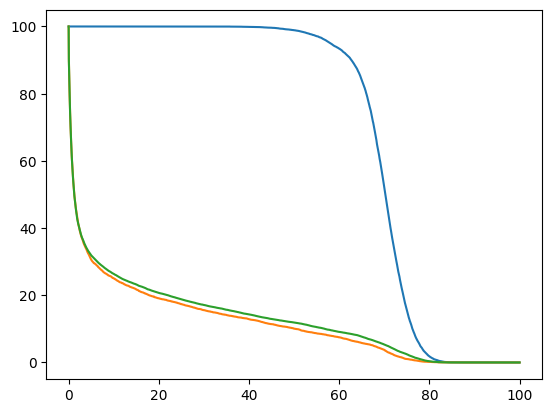

In [ ]:
import matplotlib.pyplot as plt

plt.plot(target_DVH.histogram[0], target_DVH.histogram[1])
plt.plot(rectum_DVH.histogram[0], rectum_DVH.histogram[1])
plt.plot(bladder_DVH.histogram[0], bladder_DVH.histogram[1])

Cobertura del PTV

In [ ]:
print(f'Cobertura del PTV D95: {target_DVH.D95} Gy y D5: {target_DVH.D5}')

Cobertura del PTV D95: 57.994140625 Gy y D5: 77.95355902777777
